# GNG with delayed weights

It's interesting that my bug seemed to accelerate the convergence by only using the initial weights. Does this generalize to more complicated tasks/networks? Doing this on CIFAR100 might be a better indicator wheth

## Imports and model def 

In [1]:
from timeit import timeit

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
import jax.numpy as jnp
from typing import Sequence, List, Tuple, Callable
import flax.linen as nn
from flax.training import train_state
import optax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import itertools
from jax.scipy.linalg import block_diag
import optax
from datasets import load_dataset
from functools import partial


from jax import random
# Seeding for random operations
main_rng = random.PRNGKey(42)

# For viz
import treescope
treescope.basic_interactive_setup(
    autovisualize_arrays=True,
    abbreviation_threshold=2, 
)
treescope.register_as_default()


In [2]:
def img_to_patch(x, patch_size, flatten_channels=True):
    """
    Inputs:
        x - torch.Tensor representing the image of shape [B, H, W, C]
        patch_size - Number of pixels per dimension of the patches (integer)
        flatten_channels - If True, the patches will be returned in a flattened format
                           as a feature vector instead of a image grid.
    """
    B, H, W, C = x.shape
    x = x.reshape(B, H//patch_size, patch_size, W//patch_size, patch_size, C)
    x = x.transpose(0, 1, 3, 2, 4, 5)    # [B, H', W', p_H, p_W, C]
    x = x.reshape(B, -1, *x.shape[3:])   # [B, H'*W', p_H, p_W, C]
    if flatten_channels:
        x = x.reshape(B, x.shape[1], -1) # [B, H'*W', p_H*p_W*C]
    return x

In [3]:
class AttentionBlock(nn.Module):
    embed_dim : int   # Dimensionality of input and attention feature vectors
    hidden_dim : int  # Dimensionality of hidden layer in feed-forward network
    num_heads : int   # Number of heads to use in the Multi-Head Attention block
    # dropout_prob : float = 0.0  # Amount of dropout to apply in the feed-forward network

    def setup(self):
        self.attn = nn.MultiHeadDotProductAttention(num_heads=self.num_heads)
        self.linear = [
            nn.Dense(self.hidden_dim),
            nn.gelu,
            # nn.Dropout(self.dropout_prob),
            nn.Dense(self.embed_dim)
        ]
        self.layer_norm_1 = nn.LayerNorm()
        self.layer_norm_2 = nn.LayerNorm()
        # self.dropout = nn.Dropout(self.dropout_prob)

    def __call__(self, x):
        inp_x = self.layer_norm_1(x)
        attn_out = self.attn(inputs_q=inp_x, inputs_kv=inp_x)
        # x = x + self.dropout(attn_out, deterministic=not train)
        x = x + attn_out

        linear_out = self.layer_norm_2(x)
        for l in self.linear:
            linear_out = l(linear_out)
        # x = x + self.dropout(linear_out, deterministic=not train)
        x = x + linear_out
        
        return x

In [4]:
class Preprocessor(nn.Module):
    embed_dim: int
    patch_size: int
    num_patches: int

    def setup(self):
        self.input_layer = nn.Dense(self.embed_dim)
        self.pos_embedding = self.param('pos_embedding',
                                        nn.initializers.normal(stddev=1.0),
                                        (1, 1 + self.num_patches, self.embed_dim))
        self.cls_token = self.param('cls_token',
                                    nn.initializers.normal(stddev=1.0),
                                    (1, 1, self.embed_dim))

    def __call__(self, x):
        # Preprocess input
        x = img_to_patch(x, self.patch_size)
        B, T, _ = x.shape
        x = self.input_layer(x)

        # Add CLS token and positional encoding
        cls_token = self.cls_token.repeat(B, axis=0)
        x = jnp.concatenate([cls_token, x], axis=1)
        x = x + self.pos_embedding[:, :T + 1]
        return x


class ClassificationHead(nn.Module):
    embed_dim: int
    num_classes: int

    def setup(self):
        self.mlp_head = nn.Sequential([
            nn.LayerNorm(),
            nn.Dense(self.num_classes)
        ])

    def __call__(self, x):
        # Perform classification prediction
        cls = x[:, 0]
        out = self.mlp_head(cls)
        return out


class VisionTransformer(nn.Module):
    embed_dim: int     # Dimensionality of input and attention feature vectors
    hidden_dim: int    # Dimensionality of hidden layer in feed-forward network
    num_heads: int     # Number of heads to use in the Multi-Head Attention block
    num_channels: int  # Number of channels of the input (3 for RGB)
    num_layers: int    # Number of layers to use in the Transformer
    num_classes: int   # Number of classes to predict
    patch_size: int    # Number of pixels that the patches have per dimension
    num_patches: int   # Maximum number of patches an image can have
    # dropout_prob: float = 0.0  # Amount of dropout to apply in the feed-forward network

    def setup(self):
        # All layers
        self.layers = [Preprocessor(self.embed_dim, self.patch_size, self.num_patches)] + [
            AttentionBlock(self.embed_dim,
                                           self.hidden_dim,
                                           self.num_heads,
                                           ) for _ in range(self.num_layers)
        ] + [ClassificationHead(self.embed_dim, self.num_classes)]


    def __call__(self, x, layer_out: bool = False) -> Tuple[jax.Array, List[jax.Array]]:
        intermediate_inputs = [x]
        y = x
        
        # Apply Transformer
        for i, layer in enumerate(self.layers):
            y = layer(y)
            y = self.perturb(f'layer_{i+1}', y)
            intermediate_inputs.append(y)
            
        # The final `y` is the final output. The inputs list is one item too long.
        final_output = intermediate_inputs.pop()

        if not layer_out:
            return final_output
            
        return final_output, intermediate_inputs


    def get_jacobian_calculators(self) -> List[Callable]:
        """
        Creates a list of functions that compute the Jacobian of each layer's
        output with respect to its parameters.

        This method is called via `model.apply(..., method=...)`, which ensures
        that `self.layers` is available.

        Adapted for VisualTransformer, noting that the middle layers are the same functions as they're all 
        just self-attention. 
        """
        jacobian_fns = []

        def layer_apply_fn(layer_instance: nn.Module, params: dict, layer_input: jax.Array) -> jax.Array:
            """A wrapper to call a single layer's apply method."""
            return layer_instance.apply({'params': params}, layer_input)

        # Compute Jacobian for the preprocessor layer
        # jacobian_fns.append(jax.jacrev(partial(layer_apply_fn, self.layers[0]), argnums=0))
        jacobian_fns.append(jax.jacfwd(partial(layer_apply_fn, self.layers[0]), argnums=0))
    
        # Compute Jacobian for one representative attention block
        attention_block = self.layers[1]  # Assuming all middle layers are identical
        # attention_jac_fn = jax.jacrev(partial(layer_apply_fn, attention_block), argnums=0)
        attention_jac_fn = jax.jacfwd(partial(layer_apply_fn, attention_block), argnums=0)
    
        # Reuse the Jacobian function for all identical attention blocks
        jacobian_fns.extend([attention_jac_fn] * self.num_layers)
    
        # Compute Jacobian for the classification head
        # jacobian_fns.append(jax.jacrev(partial(layer_apply_fn, self.layers[-1]), argnums=0))
        jacobian_fns.append(jax.jacfwd(partial(layer_apply_fn, self.layers[-1]), argnums=0))

        return jacobian_fns



In [16]:
def get_datasets():
    """Load CIFAR-100 train and test datasets into memory."""
    # Load the CIFAR-100 dataset
    dataset = load_dataset('cifar100')

    # Convert datasets to numpy arrays
    train_ds = {
        'image': jnp.array(dataset['train']['img']),
        'label': jnp.array(dataset['train']['fine_label'])
    }
    test_ds = {
        'image': jnp.array(dataset['test']['img']),
        'label': jnp.array(dataset['test']['fine_label'])
    }

    # Normalize the images
    train_ds['image'] = train_ds['image'].astype(jnp.float32) / 255.0
    test_ds['image'] = test_ds['image'].astype(jnp.float32) / 255.0

    # No need to reshape, CIFAR-100 images are already in the correct shape (32, 32, 3)
    
    return train_ds, test_ds

In [7]:
dataset = load_dataset('cifar100')


In [17]:
# Get datasets as dict of JAX arrays.
train_ds, test_ds = get_datasets()

## Train with Adam/SGD

In [63]:
def train_model_sgd(train_ds, test_ds, model, params, learning_rate, num_epochs,
                   bsz:int = 32):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    # optimizer = optax.adamw(learning_rate)
    state = train_state.TrainState.create(
        apply_fn=model.apply, params=params['params'], tx=optimizer
    )

    @jax.jit
    def train_step(state, batch_X, labels):
        def loss_fn(params):
            logits = state.apply_fn(params, batch_X)
            one_hot = jax.nn.one_hot(labels, 100)
            loss = jnp.mean(optax.softmax_cross_entropy(logits=logits, labels=one_hot))
            return loss, logits

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, logits), grads = grad_fn({'params': state.params})
        state = state.apply_gradients(grads=grads['params'])

        accuracy = jnp.mean(jnp.argmax(logits, -1) == labels)
        return state, loss, accuracy

    def evaluate_model(state):
        """Evaluate the model on the test dataset and return the accuracy."""
        @jax.jit
        def eval_step(params, batch_X):
            logits = model.apply(params, batch_X)
            return logits

        test_ds_size = len(test_ds['image'])
        steps_per_epoch = test_ds_size // bsz

        accuracy_list = []

        for i in range(steps_per_epoch):
            batch_images = test_ds['image'][i * bsz:(i + 1) * bsz, ...]
            batch_labels = test_ds['label'][i * bsz:(i + 1) * bsz]

            logits = eval_step({'params': state.params}, batch_images)
            accuracy = jnp.mean(jnp.argmax(logits, -1) == batch_labels)
            accuracy_list.append(accuracy)

        # Calculate the overall accuracy
        overall_accuracy = jnp.mean(jnp.array(accuracy_list))
        return overall_accuracy
    
    print(f"Starting training for {num_epochs} epochs...")
    
    train_ds_size = len(train_ds['image'])
    steps_per_epoch = train_ds_size // bsz

    rng = jax.random.PRNGKey(0)
    perms = jax.random.permutation(rng, len(train_ds['image']))
    perms = perms[: steps_per_epoch * bsz]  # skip incomplete batch
    perms = perms.reshape((steps_per_epoch, bsz))

    epoch_loss = []
    epoch_accuracy = []
    epoch_test_acc = []
    
    for _ in tqdm(range(num_epochs)):
        for perm in tqdm(perms, leave=False):
            batch_images = train_ds['image'][perm, ...]
            batch_labels = train_ds['label'][perm, ...]

            state, loss, accuracy = train_step(state, batch_images, batch_labels)
            epoch_loss.append(loss)
            epoch_accuracy.append(accuracy)
            
        epoch_test_acc.append(evaluate_model(state))
    return state, epoch_loss, epoch_accuracy, epoch_test_acc

num_epochs = 40

key = jax.random.PRNGKey(0)
model = VisionTransformer(embed_dim=32, # Make these numbers small for testing first
                              hidden_dim=32 * 4,
                              num_heads=4,
                              num_channels=3,
                              num_layers=24,
                              num_classes=100,
                              patch_size=4,
                              num_patches=64,
                             )


params = model.init(key, jnp.ones((1, 32, 32, 3)))
print(sum(x.size for x in jax.tree.leaves(params['params'])))
 
# Train the model
trained_state_sgd, sgd_losses, sgd_accuracy, sgd_test_acc = train_model_sgd(
    train_ds, test_ds, model, params, learning_rate=1e-2, num_epochs=num_epochs, bsz=256
)

311940
Starting training for 40 epochs...


  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

...

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

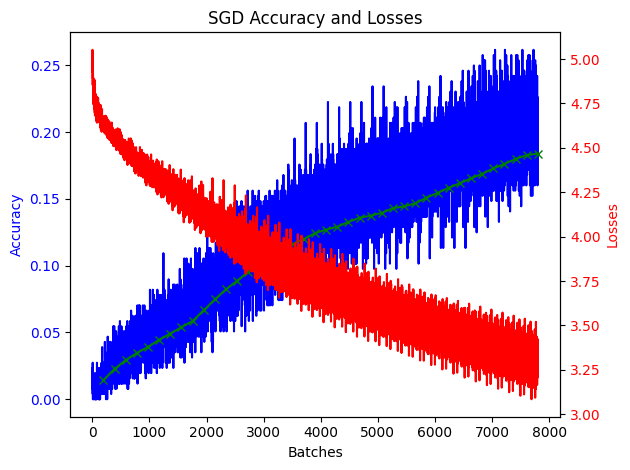

In [64]:
# Create the figure and the first axis
fig, ax1 = plt.subplots()
ax1.plot(sgd_accuracy, color='b', label='SGD Accuracy')
ax1.plot(jnp.arange(1, 1 + num_epochs) * int(len(sgd_accuracy) / num_epochs), sgd_test_acc, 'x-', color='g')
ax1.set_xlabel('Batches')
ax1.set_ylabel('Accuracy', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(sgd_losses, color='r', label='SGD Losses')
ax2.set_ylabel('Losses', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('SGD Accuracy and Losses')
fig.tight_layout()  #
plt.show()

## Try a delayed GNG method

In [62]:
def train_model_naive_precond(train_ds, test_ds, model, params, learning_rate, num_epochs,
                   bsz:int = 64, use_initial: bool=False):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(
        apply_fn=model.apply, params=params['params'], tx=optimizer
    )

    def evaluate_model(state):
        """Evaluate the model on the test dataset and return the accuracy."""
        @jax.jit
        def eval_step(params, batch_X):
            logits = model.apply(params, batch_X)
            return logits

        test_ds_size = len(test_ds['image'])
        steps_per_epoch = test_ds_size // bsz

        accuracy_list = []

        for i in range(steps_per_epoch):
            batch_images = test_ds['image'][i * bsz:(i + 1) * bsz, ...]
            batch_labels = test_ds['label'][i * bsz:(i + 1) * bsz]

            logits = eval_step({'params': state.params}, batch_images)
            accuracy = jnp.mean(jnp.argmax(logits, -1) == batch_labels)
            accuracy_list.append(accuracy)

        # Calculate the overall accuracy
        overall_accuracy = jnp.mean(jnp.array(accuracy_list))
        return overall_accuracy

    @jax.jit
    def train_step(state, batch_X, labels):
        one_hot = jax.nn.one_hot(labels, 100)
        def loss_fn(params):
            logits = state.apply_fn(params, batch_X)
            loss = jnp.mean(optax.softmax_cross_entropy(logits=logits, labels=one_hot))
            return loss, logits

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, logits), grads = grad_fn({'params': state.params})

        if use_initial:
            jacobian = jax.jacobian(model.apply, argnums=0)(params, batch_X)['params']
        else:
            jacobian = jax.jacobian(model.apply, argnums=0)(
                {'params': state.params}, batch_X
            )['params']
        flattened, _ = jax.tree.flatten(
            jacobian
        )

        reshaped_leaves = [leaf.reshape(
            bsz * 100, 1, -1) for leaf in flattened]
        aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
        J = aggregated_array.reshape((bsz * 100, -1))
        # treescope.display(J)
        
        # Generalized Gauss-Newton is J^THJ
        probs = jax.nn.softmax(logits, axis=-1).flatten()
        diag_probs = jnp.diag(probs)
        outer_probs = jnp.outer(probs, probs)
        H = diag_probs - outer_probs

        flattened, back = jax.flatten_util.ravel_pytree(grads)
        altered = jnp.linalg.solve(J.T @ H @ J + 0.1 *  jnp.eye(J.shape[1]), flattened)
        grads = back(altered)

        state = state.apply_gradients(grads=grads['params'])

        accuracy = jnp.mean(jnp.argmax(logits, -1) == labels)
        return state, loss, accuracy
    
    print(f"Starting training for {num_epochs} epochs...")
    
    train_ds_size = len(train_ds['image'])
    steps_per_epoch = train_ds_size // bsz

    rng = jax.random.PRNGKey(0)
    perms = jax.random.permutation(rng, len(train_ds['image']))
    perms = perms[: steps_per_epoch * bsz]  # skip incomplete batch
    perms = perms.reshape((steps_per_epoch, bsz))

    epoch_loss = []
    epoch_accuracy = []
    
    for _ in tqdm(range(num_epochs)):
        for perm in tqdm(perms):
            batch_images = train_ds['image'][perm, ...]
            batch_labels = train_ds['label'][perm, ...]

            state, loss, accuracy = train_step(state, batch_images, batch_labels)
            epoch_loss.append(loss)
            epoch_accuracy.append(accuracy)
        epoch_test_acc.append(evaluate_model(state))
        
    return state, epoch_loss, epoch_accuracy

num_epochs = 3

key = jax.random.PRNGKey(0)

model = VisionTransformer(embed_dim=32, # Make these numbers small for testing first
                              hidden_dim=32 * 4,
                              num_heads=4,
                              num_channels=3,
                              num_layers=1,
                              num_classes=100,
                              patch_size=4,
                              num_patches=64,
                             )

params = model.init(key, jnp.ones((1, 32, 32, 3)))
print(sum(x.size for x in jax.tree.leaves(params['params'])))
 
# Train the model
trained_state_precond_naive_init, precond_losses_naive_init, precond_accuracy_naive_init = train_model_naive_precond(
    train_ds, test_ds, model, params, learning_rate=1e-2, num_epochs=num_epochs, use_initial=True
)

19748
Starting training for 3 epochs...


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/781 [00:00<?, ?it/s]

2025-08-14 08:58:23.787025: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3425] Can't reduce memory use below 56.46GiB (60629149549 bytes) by rematerialization; only reduced to 168.55GiB (180982583068 bytes), down from 171.77GiB (184434657836 bytes) originally
2025-08-14 08:58:38.216388: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 168.55GiB (rounded to 180982441984)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-08-14 08:58:38.225508: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] ***_________________________________________________________________________________________________
E0814 08:58:38.225523  259010 pjrt_stream_executor_client.cc:2939] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memor

KeyboardInterrupt: 